<a href="https://colab.research.google.com/github/sadrabr/Deap-learning-projects/blob/main/Localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
!pip install -q tensorflow-gpu==2.0.0

try :
  %%tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf
print(tf.__version__)

ERROR: Could not find a version that satisfies the requirement tensorflow-gpu==2.0.0 (from versions: 2.12.0)
ERROR: No matching distribution found for tensorflow-gpu==2.0.0
2.18.0


In [152]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import SGD
import tensorflow as tf
from skimage.transform import resize
from tensorflow.keras.losses import binary_crossentropy, categorical_crossentropy

In [153]:
# Load images
!wget -nc https://lazyprogrammer.me/course_files/charmander-tight.png
!wget -nc https://lazyprogrammer.me/course_files/bulbasaur-tight.png
!wget -nc https://lazyprogrammer.me/course_files/squirtle-tight.png

File ‘charmander-tight.png’ already there; not retrieving.

File ‘bulbasaur-tight.png’ already there; not retrieving.

File ‘squirtle-tight.png’ already there; not retrieving.



In [154]:
!ls

backgrounds	 bulbasaur-tight.png   __MACOSX     squirtle-tight.png
backgrounds.zip  charmander-tight.png  sample_data


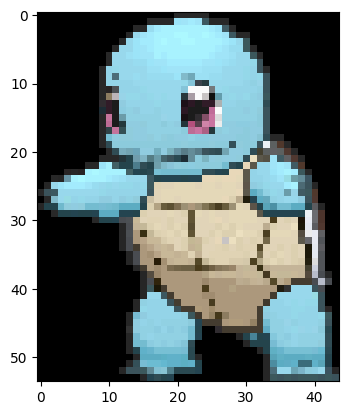

In [155]:
ch = image.load_img("charmander-tight.png")
sq = image.load_img("squirtle-tight.png")
bb = image.load_img("bulbasaur-tight.png")
plt.imshow(sq)
plt.show()

In [156]:
POKE_DIM = 200
ch = np.array(ch)
bb = np.array(bb)
sq = np.array(sq)
CH_H, CH_W, CH_C = ch.shape
BB_H, BB_W, BB_C = bb.shape
SQ_H, SQ_W, SQ_C = sq.shape

# useful store these in an array
poke_data = [
    [ch, CH_H, CH_W, CH_C],
    [bb, BB_H, BB_W, BB_C],
    [sq, SQ_H, SQ_W, SQ_C]
]
class_names = ["charmander", "bulbasaur", "squirtle"]

In [157]:
def custom_loss(y_true, y_pred):
  #(row, col, depth, width, class1, class2, class3, object_appeared)

  bce = binary_crossentropy(y_true[:,:4], y_pred[:,:4]) # location
  cce = categorical_crossentropy(y_true[:,4:7], y_pred[:,4:7]) # class
  bce2 = binary_crossentropy(y_true[:,-1], y_pred[:,-1]) # object appeared

  return bce*y_true[:,-1] + cce*y_true[:,-1] + 0.5*bce2

In [158]:
def make_model():
  vgg = tf.keras.applications.vgg16.VGG16(include_top=False, weights='imagenet', input_shape=(POKE_DIM, POKE_DIM, 3))
  x = Flatten()(vgg.output)
  x1 = Dense(4, activation='sigmoid')(x) #  location
  x2 = Dense(3, activation='sigmoid')(x) # class
  x3 = Dense(1, activation='sigmoid')(x) # object appeared
  x = tf.keras.layers.concatenate([x1, x2, x3])
  model = Model(inputs=vgg.input, outputs=x)

  model.compile(loss=custom_loss,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))
  return model

In [159]:
!wget -nc https://lazyprogrammer.me/course_files/backgrounds.zip

File ‘backgrounds.zip’ already there; not retrieving.



In [160]:
!unzip -n backgrounds.zip

Archive:  backgrounds.zip


In [161]:
from glob import glob
backgrounds = []
backgrounds_files = glob("backgrounds/*.jpg")
for f in backgrounds_files:
  bg = image.load_img(f)
  backgrounds.append(np.array(bg))

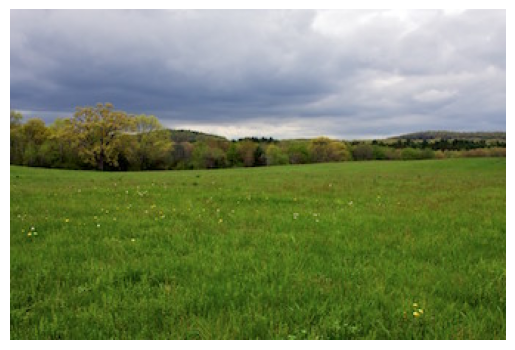

In [162]:
plt.imshow(backgrounds[np.random.randint(len(backgrounds))])
plt.axis("off")
plt.show()

In [163]:
def pokemon_generator_multiclass(batch_size=64):
  # generate image and targets
  while True:
    for _ in range(50):
      x = np.zeros((batch_size, POKE_DIM, POKE_DIM, 3))
      y = np.zeros((batch_size, 8))

      for i in range(batch_size):
        # select a random background
        bg_idx = np.random.choice(len(backgrounds))
        bg = backgrounds[bg_idx]
        bg_h, bg_w, _ = bg.shape
        rnd_h = np.random.randint(bg_h - POKE_DIM)
        rnd_w = np.random.randint(bg_w - POKE_DIM)
        x[i] = bg[rnd_h:rnd_h+POKE_DIM, rnd_w:rnd_w+POKE_DIM].copy()

        appear = (np.random.random() <0.75)
        if appear:
          pk_idx = np.random.randint(3)
          pk, pk_h, pk_w, _ = poke_data[pk_idx]

          # resize object _ make it bigger or smalller
          scale = 0.5 + np.random.random()
          new_height = int(scale*pk_h)
          new_width = int(scale*pk_w)
          obj = resize(pk, (new_height, new_width),
                      preserve_range=True).astype('uint8')

          if np.random.random() < 0.5:
            # flip horizontally
            obj = np.fliplr(obj)

          # choose a random lacation to store the object
          row0 = np.random.randint(POKE_DIM - new_height)
          col0 = np.random.randint(POKE_DIM - new_width)
          row1 = row0 + new_height
          col1 = col0 + new_width

          # since the trasparent parts will be black (0)
          mask = np.all(obj[:, :, :3] == [0, 0, 0], axis=-1)
          mask = np.expand_dims(mask, -1)
          bg_slice = x[i,row0:row1,col0:col1,:] # where we want to place "obj"
          bg_slice = mask * bg_slice
          bg_slice += obj[:,:,:3] # add the pokemon to the slice
          x[i,row0:row1,col0:col1,:] = bg_slice # put the slice back

          # make targets

          # location
          y[i,0] = row0/POKE_DIM
          y[i,1] = col0/POKE_DIM
          y[i,2] = (row1-row0)/POKE_DIM
          y[i,3] = (col1-col0)/POKE_DIM

          # class
          y[i,4+pk_idx] = 1

        # did the pokemon appear?
        y[i,7] = appear
      yield x / 255. , y




In [164]:
xx = None
yy = None
for x, y in pokemon_generator_multiclass():
  xx = x
  yy = y
  break

[0.38  0.075 0.35  0.275 1.    0.    0.    1.   ]
percent no obj: 0.59375
percent charmander: 0.3125
percent bulbasaur: 0.34375
percent squirtle: 0.46875


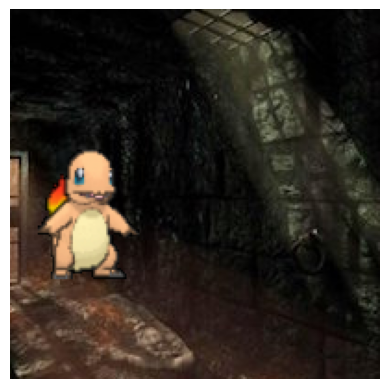

In [171]:
n = yy.shape[0]
idx = np.random.randint(n)
plt.imshow(xx[idx])
plt.axis("off")
print(yy[idx])
print("percent no obj:", (yy[:7]==0).sum()/n)
print("percent charmander:", (yy[:4]==0).sum()/n)
print("percent bulbasaur:", (yy[:5]==0).sum()/n)
print("percent squirtle:", (yy[:6]==0).sum()/n)

In [166]:
model = make_model()
model.fit(pokemon_generator_multiclass(),
          steps_per_epoch=50,
          epochs=5)


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 749ms/step - loss: 1.1046
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 783ms/step - loss: 0.4180
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 767ms/step - loss: 0.4051
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 773ms/step - loss: 0.4176
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 771ms/step - loss: 0.4076


In [167]:
def pokemon_prediction_multiclass():
    # select a random background
    bg_idx = np.random.choice(len(backgrounds))
    bg = backgrounds[bg_idx]
    bg_h, bg_w, _ = bg.shape
    rnd_h = np.random.randint(bg_h - POKE_DIM)
    rnd_w = np.random.randint(bg_w - POKE_DIM)
    x = bg[rnd_h:rnd_h+POKE_DIM, rnd_w:rnd_w+POKE_DIM].copy()

    appear = (np.random.random() <0.75)
    if appear:
      pk_idx = np.random.randint(3)
      pk, pk_h, pk_w, _ = poke_data[pk_idx]

      # resize object _ make it bigger or smalller
      scale = 0.5 + np.random.random()
      new_height = int(scale*pk_h)
      new_width = int(scale*pk_w)
      obj = resize(pk, (new_height, new_width),
                  preserve_range=True).astype('uint8')
      if np.random.random() < 0.5:
       # flip horizontally
       obj = np.fliplr(obj)
      # choose a random lacation to store the object
      row0 = np.random.randint(POKE_DIM - new_height)
      col0 = np.random.randint(POKE_DIM - new_width)
      row1 = row0 + new_height
      col1 = col0 + new_width

      # since the trasparent parts will be black (0)
      mask = np.all(obj[:, :,: 3] == [0, 0, 0], axis=-1)
      mask = np.expand_dims(mask, -1)
      bg_slice = x[row0:row1,col0:col1,:] # where we want to place "obj"
      bg_slice = mask * bg_slice
      bg_slice += obj[:,:,:3] # add the pokemon to the slice
      x[row0:row1,col0:col1,:] = bg_slice # put the slice back
      actual_class = class_names[pk_idx]
      print("trues:",row0,col0,row1,col1,actual_class)

    # predict
    x = np.expand_dims(x, 0) / 255.
    p = model.predict(x)[0]

    # plot
    fig, ax = plt.subplots(1)
    # x = np.squeeze(x, axis=0)
    # ax.imshow(x.astype(np.uint8))
    ax.imshow((x[0] * 255).astype(np.uint8))

    # Draw the box
    if p[-1] >0.5:
        row0 = int(p[0]*POKE_DIM)
        col0 = int(p[1]*POKE_DIM)
        row1 = int(row0 + p[2]*POKE_DIM)
        col1 = int(col0 + p[3]*POKE_DIM)
        class_pred_idx = np.argmax(p[4:7])
        class_pred = class_names[class_pred_idx]
        print("preds:",row0,col0,row1,col1,class_pred)
        rect = Rectangle(
            (p[1]*POKE_DIM, p[0]*POKE_DIM),
            p[3]*POKE_DIM,
            p[2]*POKE_DIM,
            linewidth=1,
            edgecolor='r',
            facecolor='none'
        )
        ax.add_patch(rect)
    else:
        print("pred: no object")
    plt.show()


trues: 89 108 130 144 bulbasaur
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
preds: 91 102 125 137 bulbasaur


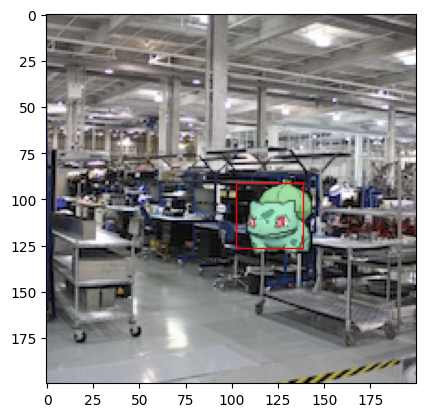

In [177]:
pokemon_prediction_multiclass()